# 5-Fold Cross-Chip Summary + Per-Label/Per-Chip XAI (`final_4_chip_clean`, SC3)

Summarizes job **272919_1** (`final_04_kfold5_crossval.sh`, `--mode kfold --n_splits 5
--supcon 3`) for group `final_4_chip_clean`, curve type `ori_curve_wavelet_bior35_norm`:

1. **Part 1** — 5-fold cross-chip accuracy bar chart, one bar per model per fold
   (mirrors `plot_accuracy_by_model()` in `result_comparison.ipynb`, adapted from
   dataset-axis to fold-axis and from `03`'s single-dataset results to `04`'s
   cross-dataset results).
2. **Part 2** — XAI on the **`--train_full` model** (trained on all 4 chips combined,
   no holdout): for every (chip, label) pair, finds the single sample with a
   **correct prediction and the highest predicted probability**, and plots it with
   `plot_per_label_saliency_heatmap` (copied verbatim from `lab_per_label_saliency.ipynb`
   — reused unmodified, only the data-selection layer around it differs).

**Defaults**: `curve_type=ori_curve_wavelet_bior35_norm`, `SC=3`,
`group=final_4_chip_clean`, XAI model=`cnn_gru_dual_attn_recon_supcon3`.

> ### ⚠️ Cache staleness warning (confirmed from the job log itself)
> Job 272919_1 ran the SC3 sweep (5 folds + `--train_full`) **before**
> `EXCLUDE_WELL_MAPPING` was extended to also drop the `PC` well (index 8) from all
> four chips — at SC3-run time only `D20260807_..._02_07` wells `[6,7]` and
> `D20260808_..._03_01` well `[6]` were excluded (59215 total samples). The
> *second* `04` call in the same job (`--supcon 0`) started **after** that config
> change and its own log line literally says:
> `[Warning] Cached results ... were built from 59215 filtered samples; current data
> has 57354 (likely changed upstream). Discarding stale cache for this filter.`
> — but that discard-and-retrain only happened for SC0's own cache check; the SC3
> results/full-data model analyzed below were already fully cached *before* the
> config change and were never recomputed. Section 3 reconstructs the exact
> `EXCLUDE_WELL_MAPPING` state the SC3 run actually used (from its own log output)
> so the XAI sample selection stays consistent with what the loaded model was
> actually trained on, and separately reports what the *current* config would give
> for comparison.


In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


In [2]:
import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Reuse 04's own data-loading/split logic and 06b's results-file discovery instead of
# reimplementing them, so this notebook always matches what the real training/reporting
# scripts actually do.
cdt = importlib.import_module("04_cross_dataset_training")
b06 = importlib.import_module("06b_cross_dataset_prediction_report")

%matplotlib inline


Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration

In [3]:
GROUP_NAME  = "final_4_chip_clean"            # key into config.CROSS_DATASET_GROUPS
EXP_FOLDER  = config.FINAL_EXP_FOLDER + "_nc_subtract"
CURVE_TYPE  = "ori_curve_wavelet_bior35_norm"
SC          = 3
MODE_STR    = "kfold5"                        # matches --mode kfold --n_splits 5

SC3_MODELS = ["cnn_gru_dual_supcon3", "cnn_gru_dual_attn_recon_supcon3"]
XAI_MODELS = ["cnn_gru_dual_attn_recon_supcon3"]   # default per user request

# XAI params (mirrors lab_per_label_saliency.ipynb)
N_DIMS       = 25
SAMPLE_SCOPE = "class"

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]
group_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME

def short_name(folder):
    return folder.split('_U_', 1)[1]

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips:")
for n in folder_names:
    print(" -", n, f"({short_name(n)})")


Group 'final_4_chip_clean' -> 4 chips:
 - D20260806_E00_C00_F4500KHz_U_DDM_01_06 (DDM_01_06)
 - D20260807_E00_C00_F4500KHz_U_DDM_02_07 (DDM_02_07)
 - D20260808_E00_C00_F4500KHz_U_DDM_03_01 (DDM_03_01)
 - D20260810_E00_C00_F4500KHz_U_DDM_04_01 (DDM_04_01)


## 2. Load the kfold5 results file

In [4]:
legacy_path = b06.find_results_path(group_dir, MODE_STR, CURVE_TYPE)
lofo_results = b06.load_partitioned(group_dir, MODE_STR, CURVE_TYPE, legacy_path=legacy_path)
assert lofo_results, f"No '{MODE_STR}' results found for {GROUP_NAME}/{CURVE_TYPE}"
print(f"Loaded results for {GROUP_NAME}/{CURVE_TYPE}")

fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")],
                     key=lambda s: int(s.split("_")[1]))
has_full_data = "full_data" in lofo_results
print(f"{len(fold_labels)} folds: {fold_labels}  |  full_data present: {has_full_data}")


Loading: /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/cross_dataset_classification_performances_kfold5_ori_curve_wavelet_bior35_norm.joblib
5 folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']  |  full_data present: True


## 3. Part 1 — 5-fold cross-chip accuracy by model (SC3)

In [5]:
rows = []
for fold in fold_labels:
    res_entry = lofo_results[fold].get(None)   # outlier_filter=None (Baseline)
    if res_entry is None:
        continue
    for m in SC3_MODELS:
        preds_key, probs_key, _ = config.MODEL_KEY_MAP[m]
        if preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        rows.append({"fold": fold, "model": m,
                     "accuracy": accuracy_score(y_true, y_pred) * 100,
                     "n_test": len(y_true)})

acc_df = pd.DataFrame(rows)
acc_df


,fold,model,accuracy,n_test
0,fold_0,cnn_gru_dual_supcon3,76.973740,11843
1,fold_0,cnn_gru_dual_attn_recon_supcon3,96.141180,11843
2,fold_1,cnn_gru_dual_supcon3,76.543106,11843
3,fold_1,cnn_gru_dual_attn_recon_supcon3,96.732247,11843
4,fold_2,cnn_gru_dual_supcon3,76.348898,11843
5,fold_2,cnn_gru_dual_attn_recon_supcon3,96.605590,11843
6,fold_3,cnn_gru_dual_supcon3,79.405556,11843
7,fold_3,cnn_gru_dual_attn_recon_supcon3,96.411382,11843


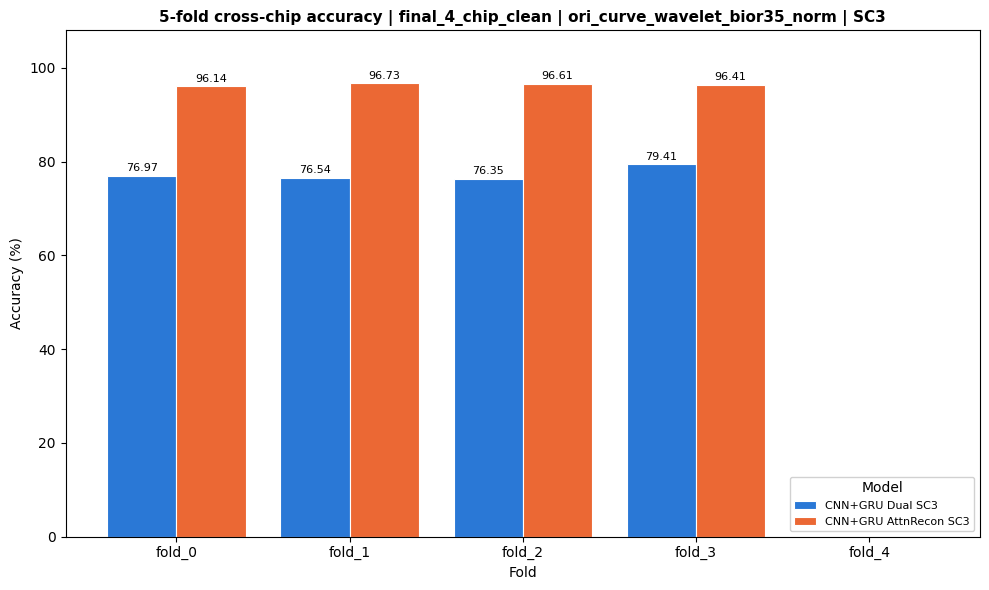

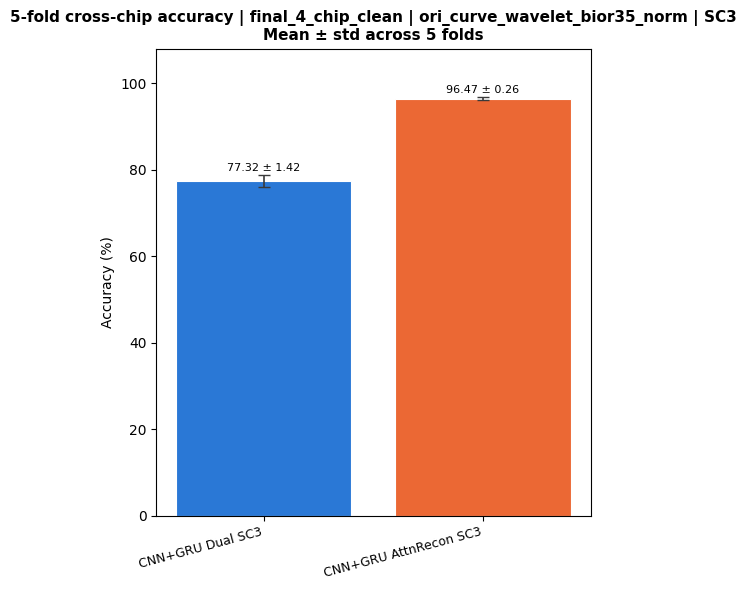


Mean ± std across folds:
                                  mean   std
model                                       
cnn_gru_dual_attn_recon_supcon3  96.47  0.26
cnn_gru_dual_supcon3             77.32  1.42


In [6]:
def plot_fold_accuracy_by_model(acc_df, fold_labels, models, title, figsize=(10, 6)):
    """Grouped bar chart: x=fold, one sub-bar per model, y=accuracy%. Then a second
    chart: x=model, y=mean accuracy% across folds, error bar=std.
    Mirrors result_comparison.ipynb's plot_accuracy_by_model(), adapted from a
    dataset-axis (03, single-experiment results) to a fold-axis (04, cross-dataset
    results)."""
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(fold_labels))

    # dataviz-skill validated categorical palette, assigned in `models` order
    palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
               '#e87ba4', '#008300', '#4a3aa7', '#e34948']

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        sub = acc_df[acc_df.model == model].set_index("fold")
        ys = np.array([sub["accuracy"].get(f, np.nan) for f in fold_labels])
        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
               color=palette[mi % len(palette)],
               label=config.MODEL_PRINT_MAP.get(model, model),
               edgecolor='white', linewidth=0.8)
        for xi, yi in zip(x + offset, ys):
            if not np.isnan(yi):
                ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 108)
    ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

    # ── 2nd plot: mean accuracy ± std across folds, one bar per model ─────────
    stats = acc_df.groupby("model")["accuracy"].agg(["mean", "std"]).reindex(models)
    x2 = np.arange(n_models)

    fig2, ax2 = plt.subplots(figsize=(1.6 * n_models + 2, 6))
    ax2.bar(x2, stats["mean"], yerr=stats["std"], capsize=4,
           color=[palette[mi % len(palette)] for mi in range(n_models)],
           edgecolor='white', linewidth=0.8,
           error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
    for xi, mean_v, std_v in zip(x2, stats["mean"], stats["std"]):
        ax2.text(xi, mean_v + std_v + 0.5, f'{mean_v:.2f} ± {std_v:.2f}',
                 ha='center', va='bottom', fontsize=8)

    ax2.set_xticks(x2)
    ax2.set_xticklabels([config.MODEL_PRINT_MAP.get(m, m) for m in models],
                        fontsize=9, rotation=15, ha='right')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(0, 108)
    ax2.set_title(f'{title}\nMean ± std across {len(fold_labels)} folds',
                  fontsize=11, fontweight='bold')
    fig2.tight_layout()
    plt.show()


plot_fold_accuracy_by_model(
    acc_df, fold_labels, SC3_MODELS,
    title=f'5-fold cross-chip accuracy | {GROUP_NAME} | {CURVE_TYPE} | SC{SC}',
)

print("\nMean ± std across folds:")
print(acc_df.groupby("model")["accuracy"].agg(["mean", "std"]).round(2))

## 4. `--train_full` model — reference numbers

Trained on all 4 chips combined, **no holdout** — this is train-set accuracy
(inflated), shown only for context/as the basis for the XAI section below, not as a
CV metric (use Section 3's fold accuracies for actual generalization performance).

In [7]:
FULL_DATA_DIRNAMES = (f"full_data_{MODE_STR}", "full_data")   # new convention, then legacy

def resolve_full_data_dir(group_dir):
    for name in FULL_DATA_DIRNAMES:
        p = group_dir / "model_interpretation" / name
        if p.exists():
            return p
    return None

full_data_dir = resolve_full_data_dir(group_dir)
assert full_data_dir is not None, f"No full_data model_interpretation dir found under {group_dir}"
print("full_data model dir:", full_data_dir)

res_full = lofo_results.get("full_data", {}).get(None)
assert res_full is not None, "No cached full_data / outlier_filter=None results in this results file."

for m in SC3_MODELS:
    preds_key, probs_key, _ = config.MODEL_KEY_MAP[m]
    if preds_key not in res_full:
        continue
    y_true = np.concatenate(res_full["y_trues_"])
    y_pred = np.concatenate(res_full[preds_key])
    print(f"  {config.MODEL_PRINT_MAP.get(m, m):24s} train-set accuracy: "
          f"{accuracy_score(y_true, y_pred)*100:.2f}%  (N={len(y_true)})")


full_data model dir: /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/full_data
  CNN+GRU Dual SC3         train-set accuracy: 86.03%  (N=59215)
  CNN+GRU AttnRecon SC3    train-set accuracy: 99.43%  (N=59215)


## 5. Part 2 — XAI: per-label, per-chip saliency on the full-data model

For each (chip, label) pair, picks the single sample with a **correct prediction and
the highest predicted probability**, using predictions/probabilities **already cached**
in `res_full` (no need to reload the model or rebuild the real spatial neighbor stack
just to reproduce predictions -- `res_full` was computed with `cv_splits=[(all_idx,
all_idx)]`, i.e. every sample in natural order, so it lines up positionally with
`combine_group()`'s output). The model is only loaded for the actual saliency/gradient
computation on the selected samples.

`plot_per_label_saliency_heatmap` and `compute_class_direct_saliency` below are copied
**verbatim** from `lab_per_label_saliency.ipynb` — reused unchanged, not reimplemented.

In [8]:
# ── sys.path + custom Keras class registration (mirrors lab_per_label_saliency.ipynb) ──
MAIN_DIR     = Path.cwd()
UTILS_DIR    = MAIN_DIR / 'utils'
UTILS_MT_DIR = UTILS_DIR / 'model_training'
for p in [str(MAIN_DIR), str(UTILS_DIR), str(UTILS_MT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

import tensorflow as tf
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import model_utils_gated   # noqa — registers _SumPool1D, _OneMinus
import model_utils_mtl     # noqa — registers MTLModel
import model_utils_supcon  # noqa — registers SupConModel variants
import model_utils_rcfd    # noqa — registers RCFDModel variants

import importlib.util
_spec = importlib.util.spec_from_file_location('xai07', MAIN_DIR / '07_attribution_vis_all.py')
xai07 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(xai07)

extract_xai_artifacts = xai07.extract_xai_artifacts
normalize_heatmap      = xai07.normalize_heatmap

print('XAI imports OK  |  TF', tf.__version__)


XAI imports OK  |  TF 2.16.2


In [9]:
# ── Copied verbatim from lab_per_label_saliency.ipynb ──────────────────────────

def compute_class_direct_saliency(
    model: tf.keras.Model,
    X_class: np.ndarray,   # (N_c, T, 1) — already filtered to the scope
    class_idx: int,
) -> np.ndarray:           # (T,) mean |d(cls[:,c])/d(X)|
    """
    Differentiates the class-c output logit w.r.t. each input sample.

    Uses reduce_sum (not reduce_mean) so that, for architectures without
    cross-sample coupling (no BatchNorm in inference mode), gradient[i] equals
    d(cls[i, c]) / d(X[i]) exactly — samples are independent and the sum
    gradient decomposes sample-wise.

    Neighbor-stack models (e.g. cnn_gru_dual_attn_recon*) take (N, k+1, T), not
    (N, T, 1) -- mirrors 07_attribution_vis_all.py's extract_xai_artifacts: repeat
    the curve k+1 times into a dummy stack, then average the gradient over the
    neighbor axis.
    """
    is_neighbor_stack = (
        not isinstance(model.input, (list, tuple))
        and hasattr(model.input, 'name')
        and 'neighbor_stack' in model.input.name
    )
    if is_neighbor_stack:
        k_plus_1 = model.input.shape[1]
        x_center = X_class[:, :, 0].astype(np.float32)                   # (N, T)
        x_var    = tf.Variable(np.stack([x_center] * k_plus_1, axis=1))  # (N, k+1, T)
        with tf.GradientTape() as tape:
            outs   = model(x_var, training=False)
            cls_t  = outs[0] if isinstance(outs, (list, tuple)) else outs
            target = tf.reduce_sum(cls_t[:, class_idx])
        grad = tape.gradient(target, x_var).numpy()        # (N_c, k+1, T)
        return np.abs(grad).mean(axis=1).mean(axis=0)      # (T,)

    x_var = tf.Variable(X_class.astype(np.float32))
    with tf.GradientTape() as tape:
        outs   = model(x_var, training=False)
        cls_t  = outs[0] if isinstance(outs, (list, tuple)) else outs
        target = tf.reduce_sum(cls_t[:, class_idx])   # sum → grad[i] = d(cls[i,c])/d(x[i])
    grad = tape.gradient(target, x_var).numpy()        # (N_c, T, 1)
    return np.abs(grad[:, :, 0]).mean(axis=0)          # (T,)


print('compute_class_direct_saliency defined.')

compute_class_direct_saliency defined.


In [10]:
# ── Copied verbatim from lab_per_label_saliency.ipynb ──────────────────────────

def plot_per_label_saliency_heatmap(
    art: dict,
    model: tf.keras.Model,
    X_batch: np.ndarray,    # (N, T, 1)
    y_batch: np.ndarray,    # (N,) int
    y_pred:  np.ndarray,    # (N,) int
    class_idx:   int,
    class_name:  str,
    timestamps:  np.ndarray,
    n_dims:       int  = 25,
    sample_scope: str  = 'class',   # 'class' | 'all'
    save_path = None,
) -> None:
    """
    1 figure per label. 4 column groups: A-Raw | A-Norm | B-Raw | B-Norm.
    Each column: curve (top, taller) -> CNN heatmap -> GRU heatmap (dual) -> 1D summary.
    View A: correctly-classified samples; summary = collapsed latent saliency Sum|dZ/dX|.
    View B: class-c samples (or all); summary = direct |d(cls_c)/dX|.
    """
    is_dual = art['is_type'] == 'dual'
    T       = len(timestamps)
    t_step  = (timestamps[-1] - timestamps[0]) / (T - 1) if T > 1 else 1.0
    t_start = timestamps[0]  - t_step / 2
    t_end   = timestamps[-1] + t_step / 2

    # ── Masks ──────────────────────────────────────────────────────────────
    mask_a    = (y_batch == class_idx) & (y_pred == class_idx)
    mask_b    = (y_batch == class_idx) if sample_scope == 'class' \
                else np.ones(len(y_batch), dtype=bool)
    n_a       = int(mask_a.sum())
    n_b       = int(mask_b.sum())
    n_total_c = int((y_batch == class_idx).sum())

    if n_a == 0:
        print(f'  [skip] {class_name}: no correctly-classified samples in batch')
        return
    if n_b == 0:
        print(f'  [skip] {class_name}: no View B samples')
        return

    # ── Heatmaps ───────────────────────────────────────────────────────────
    n_cnn = min(n_dims, len(art['raw_saliency_curve']))
    hm_a_cnn_raw  = np.array([m[mask_a].mean(0) for m in art['raw_saliency_curve'][:n_cnn]])
    hm_a_cnn_norm = normalize_heatmap(hm_a_cnn_raw, method='row')
    hm_b_cnn_raw  = np.array([m[mask_b].mean(0) for m in art['raw_saliency_curve'][:n_cnn]])
    hm_b_cnn_norm = normalize_heatmap(hm_b_cnn_raw, method='row')

    if is_dual:
        n_rnn   = min(n_dims, len(art['raw_saliency_rnn']))
        _branch = 'Trans' if any('trans' in l.name for l in model.layers) else 'GRU'
        hm_a_rnn_raw  = np.array([m[mask_a].mean(0) for m in art['raw_saliency_rnn'][:n_rnn]])
        hm_a_rnn_norm = normalize_heatmap(hm_a_rnn_raw, method='row')
        hm_b_rnn_raw  = np.array([m[mask_b].mean(0) for m in art['raw_saliency_rnn'][:n_rnn]])
        hm_b_rnn_norm = normalize_heatmap(hm_b_rnn_raw, method='row')

    # ── 1-D summary signals ────────────────────────────────────────────────
    def _norm1d(x):
        return (x - x.min()) / (x.ptp() + 1e-12)

    # View A: collapse heatmap over latent-dim axis -> temporal summary
    _a_raw_sum = hm_a_cnn_raw.mean(0)
    _a_nrm_sum = hm_a_cnn_norm.mean(0)
    if is_dual:
        _a_raw_sum = _a_raw_sum + hm_a_rnn_raw.mean(0)
        _a_nrm_sum = _a_nrm_sum + hm_a_rnn_norm.mean(0)
    sal_a_raw_1d = _norm1d(_a_raw_sum)
    sal_a_nrm_1d = _norm1d(_a_nrm_sum)

    # View B: direct class gradient |d(cls_c)/dX| -> (T,)
    sal_b_1d = _norm1d(
        compute_class_direct_saliency(model, X_batch[mask_b], class_idx)
    )

    # ── Mean curves ────────────────────────────────────────────────────────
    mean_a = X_batch[mask_a, :, 0].mean(0)
    std_a  = X_batch[mask_a, :, 0].std(0)
    mean_b = X_batch[mask_b, :, 0].mean(0)
    std_b  = X_batch[mask_b, :, 0].std(0)

    # ── Figure / GridSpec ──────────────────────────────────────────────────
    n_hm   = 2 if is_dual else 1
    hr     = [1.8] + [3.2] * n_hm + [1.3]
    n_rows = 1 + n_hm + 1
    fig    = plt.figure(figsize=(28 if is_dual else 22, 17 if is_dual else 12),
                        facecolor='white')
    outer  = gridspec.GridSpec(1, 2, wspace=0.42, figure=fig)
    kw     = dict(height_ratios=hr, hspace=0.20, wspace=0.24)
    gs_a   = gridspec.GridSpecFromSubplotSpec(n_rows, 2, subplot_spec=outer[0], **kw)
    gs_b   = gridspec.GridSpecFromSubplotSpec(n_rows, 2, subplot_spec=outer[1], **kw)

    def _curve(gs, col, mean_c, std_c, n_samp, title):
        ax = fig.add_subplot(gs[0, col])
        ax.plot(timestamps, mean_c, color='#16213E', lw=1.7)
        ax.fill_between(timestamps, mean_c - std_c, mean_c + std_c,
                        color='gray', alpha=0.22, label=f'±1σ  N={n_samp}')
        ax.set_title(title, fontsize=8.5, fontweight='bold', pad=5)
        ax.set_xlim(t_start, t_end)
        ax.legend(fontsize=7, loc='upper left', framealpha=0.8)
        ax.grid(True, color='grey', alpha=0.22, ls='--')
        ax.tick_params(labelsize=7)
        plt.setp(ax.get_xticklabels(), visible=False)
        return ax

    def _heatmap(gs, row, col, hm, title, ref_ax, vmin=None, vmax=None):
        ax = fig.add_subplot(gs[row, col], sharex=ref_ax)
        im = ax.imshow(
            hm, aspect='auto', cmap='inferno',
            vmin=vmin, vmax=vmax,
            extent=[t_start, t_end, len(hm), 0],
            interpolation='nearest',
        )
        ax.set_title(title, fontsize=7.5, fontweight='bold', pad=3)
        ax.set_ylabel('Latent rank', fontsize=7)
        ax.tick_params(labelsize=6.5)
        ax.grid(True, color='grey', alpha=0.17, ls='--')
        cax = make_axes_locatable(ax).append_axes('right', size='3%', pad=0.04)
        fig.colorbar(im, cax=cax).set_label(
            '|∂Z/∂X|', rotation=270, labelpad=8, fontsize=6.5
        )
        plt.setp(ax.get_xticklabels(), visible=False)
        return ax

    def _summary(gs, col, mean_c, sal_norm, ref_ax, fill_col, title):
        ax  = fig.add_subplot(gs[n_rows - 1, col], sharex=ref_ax)
        ax2 = ax.twinx()
        ax.plot(timestamps, mean_c, color='#16213E', lw=1.2, alpha=0.75)
        ax2.fill_between(timestamps, 0, sal_norm, color=fill_col, alpha=0.38)
        ax2.plot(timestamps, sal_norm, color=fill_col, lw=1.0, alpha=0.9)
        ax2.set_ylim(0, 2.2)
        ax2.set_yticks([])
        ax.set_xlabel('Time (min)', fontsize=7.5)
        ax.set_ylabel('Fluor.', fontsize=7, color='#16213E')
        ax.set_title(title, fontsize=7.5, fontweight='bold', pad=3)
        ax.grid(True, color='grey', alpha=0.20, ls='--')
        ax.tick_params(labelsize=6.5)
        return ax

    ax_a0 = _curve(gs_a, 0, mean_a, std_a, n_a,
                   f'A (Raw)  {class_name}  correct N={n_a}/{n_total_c}')
    ax_a1 = _curve(gs_a, 1, mean_a, std_a, n_a,
                   f'A (Norm)  {class_name}  correct N={n_a}/{n_total_c}')
    if is_dual:
        _heatmap(gs_a, 1, 0, hm_a_cnn_raw,  f'CNN — Raw  (top {n_cnn})',       ax_a0)
        _heatmap(gs_a, 1, 1, hm_a_cnn_norm, 'CNN — Normalised',                 ax_a1, vmin=0, vmax=1)
        _heatmap(gs_a, 2, 0, hm_a_rnn_raw,  f'{_branch} — Raw  (top {n_rnn})', ax_a0)
        _heatmap(gs_a, 2, 1, hm_a_rnn_norm, f'{_branch} — Normalised',          ax_a1, vmin=0, vmax=1)
    else:
        _heatmap(gs_a, 1, 0, hm_a_cnn_raw,  f'Raw  (top {n_cnn})', ax_a0)
        _heatmap(gs_a, 1, 1, hm_a_cnn_norm, 'Normalised',           ax_a1, vmin=0, vmax=1)
    _summary(gs_a, 0, mean_a, sal_a_raw_1d, ax_a0,
             fill_col='#1565C0', title='Σ|∂Z/∂X| (raw)')
    _summary(gs_a, 1, mean_a, sal_a_nrm_1d, ax_a1,
             fill_col='#1565C0', title='Σ|∂Z/∂X| (row-norm)')

    scope_str = f'{class_name} only' if sample_scope == 'class' else 'all samples'
    ax_b0 = _curve(gs_b, 0, mean_b, std_b, n_b,
                   f'B (Raw)  {class_name}  {scope_str} N={n_b}')
    ax_b1 = _curve(gs_b, 1, mean_b, std_b, n_b,
                   f'B (Norm)  {class_name}  {scope_str} N={n_b}')
    if is_dual:
        _heatmap(gs_b, 1, 0, hm_b_cnn_raw,  f'CNN — Raw  (top {n_cnn})',       ax_b0)
        _heatmap(gs_b, 1, 1, hm_b_cnn_norm, 'CNN — Normalised',                 ax_b1, vmin=0, vmax=1)
        _heatmap(gs_b, 2, 0, hm_b_rnn_raw,  f'{_branch} — Raw  (top {n_rnn})', ax_b0)
        _heatmap(gs_b, 2, 1, hm_b_rnn_norm, f'{_branch} — Normalised',          ax_b1, vmin=0, vmax=1)
    else:
        _heatmap(gs_b, 1, 0, hm_b_cnn_raw,  f'Raw  (top {n_cnn})', ax_b0)
        _heatmap(gs_b, 1, 1, hm_b_cnn_norm, 'Normalised',           ax_b1, vmin=0, vmax=1)
    _summary(gs_b, 0, mean_b, sal_b_1d, ax_b0,
             fill_col='#E64A19', title='|d(cls_c)/dX|  (norm)')
    _summary(gs_b, 1, mean_b, sal_b_1d, ax_b1,
             fill_col='#E64A19', title='|d(cls_c)/dX|  (norm)')

    fig.suptitle(
        f'{class_name}  |  {art["is_type"].upper()} model  |  '
        f'A: correct N={n_a}/{n_total_c}  ◆  B: {scope_str} N={n_b}',
        fontsize=11, fontweight='bold', y=1.01,
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()

print('plot_per_label_saliency_heatmap defined.')


plot_per_label_saliency_heatmap defined.


### 5a. Reconstruct the exact data the SC3 / full-data run used

In [11]:
# ── Disk cache for this notebook's heavy recomputations ─────────────────────
# combine_group (curve resampling across 4 chips) and extract_xai_artifacts
# (gradient tape over the whole model, up to ~100+100 backward passes per batch)
# are the expensive steps below. load_or_compute caches each to a joblib file next
# to the notebook's other outputs, so a kernel restart / re-run reuses prior work
# instead of redoing it. Delete the cache file to force a recompute.
from safe_io import safe_joblib_dump

def load_or_compute(path, compute_fn, label="result"):
    path = Path(path)
    if path.exists():
        print(f"  [cache hit] {label} <- {path}")
        return joblib.load(path)
    result = compute_fn()
    safe_joblib_dump(result, path, compress=3)
    print(f"  [cache save] {label} -> {path}")
    return result

In [12]:
# Reconstructed from job 272919_1's SC3 run log output (the "[*] EXCLUDE_WELL_MAPPING:
# dropping N samples ..." lines printed during that specific python invocation) --
# NOT the current config.EXCLUDE_WELL_MAPPING, which has since grown to also exclude
# the PC well from all 4 chips. This snapshot is only used to rebuild the pool that
# lines up with the already-cached full_data predictions/probabilities.
EXCLUDE_WELL_MAPPING_AS_OF_JOB = {
    'D20260807_E00_C00_F4500KHz_U_DDM_02_07': [6, 7],
    'D20260808_E00_C00_F4500KHz_U_DDM_03_01': [6],
}

def combine_group_with_mapping(exp_paths, group_name, curve_type, mapping_snapshot):
    """mapping_snapshot reconstructs the flat config.EXCLUDE_WELL_MAPPING as it
    existed when job 272919_1 ran -- predates LOFO_EXCLUDE_WELL_MAPPING's group-
    scoped exclusion, so this deliberately passes None (not group_name) as
    cdt.combine_group's group_name arg, to keep it on flat-mapping semantics
    instead of switching to LOFO_EXCLUDE_WELL_MAPPING[group_name]."""
    saved = dict(config.EXCLUDE_WELL_MAPPING)
    config.EXCLUDE_WELL_MAPPING.clear()
    config.EXCLUDE_WELL_MAPPING.update(mapping_snapshot)
    try:
        return cdt.combine_group(exp_paths, None, curve_type=curve_type)
    finally:
        config.EXCLUDE_WELL_MAPPING.clear()
        config.EXCLUDE_WELL_MAPPING.update(saved)


combined_current = load_or_compute(
    group_dir / "model_interpretation" / f"combined_current_{CURVE_TYPE}.joblib",
    lambda: cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE),
    label="combined_current",
)
combined = load_or_compute(
    group_dir / "model_interpretation" / f"combined_asofjob_{CURVE_TYPE}.joblib",
    lambda: combine_group_with_mapping(exp_paths, GROUP_NAME, CURVE_TYPE,
                                       EXCLUDE_WELL_MAPPING_AS_OF_JOB),
    label="combined (as-of-job mapping)",
)

n_cached = len(res_full["y_trues_"][0])
print(f"Current LOFO_EXCLUDE_WELL_MAPPING[{GROUP_NAME!r}] -> {len(combined_current['Y_mapped'])} samples")
print(f"As-of-job (272919_1 SC3 run)        -> {len(combined['Y_mapped'])} samples")
print(f"Cached full_data result             -> {n_cached} samples")

  [cache hit] combined_current <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/combined_current_ori_curve_wavelet_bior35_norm.joblib
  [cache hit] combined (as-of-job mapping) <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/combined_asofjob_ori_curve_wavelet_bior35_norm.joblib
Current config.EXCLUDE_WELL_MAPPING -> 57354 samples
As-of-job (272919_1 SC3 run)        -> 59215 samples
Cached full_data result             -> 59215 samples


In [13]:
# Hard alignment gate -- if this doesn't hold, the (chip,label) selection below would
# silently pick the wrong sample / attach the wrong label to the wrong curve, so this
# must pass before continuing (see evaluate_outlier_filters' own analogous staleness
# check that fired mid-job for the SC0 run in this same log).
enc = LabelEncoder()
y_full = enc.fit_transform(combined["Y_mapped"])
class_names = list(enc.classes_)
y_true_cached = np.asarray(res_full["y_trues_"][0])

assert y_full.shape == y_true_cached.shape and np.array_equal(y_full, y_true_cached), (
    "Reconstructed 'as-of-job' pool doesn't match cached full_data y_trues_ -- "
    "EXCLUDE_WELL_MAPPING_AS_OF_JOB may be incomplete, or LABEL_MAPPINGS changed too. "
    "Re-derive the snapshot from job 272919_1's own log output."
)
print(f"Alignment OK -- {len(y_full)} samples, {len(class_names)} classes: {class_names}")


Alignment OK -- 59215 samples, 7 classes: ['Cov', 'Hadv', 'IAV', 'IBV', 'Kp', 'NC', 'PC']


### 5b. Select the highest-confidence correctly-predicted sample per (chip, label)

In [14]:
def select_best_correct_samples(combined, y_full, y_pred, y_prob, class_names):
    records = []
    dataset_ids = combined["dataset_id"]
    for chip in sorted(np.unique(dataset_ids)):
        chip_mask = dataset_ids == chip
        chip_labels = sorted(np.unique(y_full[chip_mask]))
        for label_idx in chip_labels:
            label_name = class_names[label_idx]
            m = chip_mask & (y_full == label_idx) & (y_pred == label_idx)
            n_correct = int(m.sum())
            n_total = int((chip_mask & (y_full == label_idx)).sum())
            if n_correct == 0:
                print(f"  [skip] {short_name(chip)} / {label_name}: "
                      f"no correct predictions ({n_total} samples)")
                continue
            cand_idx = np.where(m)[0]
            best = cand_idx[np.argmax(y_prob[cand_idx, label_idx])]
            records.append({
                "chip": chip, "chip_short": short_name(chip),
                "label_idx": label_idx, "label": label_name,
                "row_idx": int(best),
                "confidence": float(y_prob[best, label_idx]),
                "n_correct": n_correct, "n_total": n_total,
            })
    return pd.DataFrame(records)


XAI_MODEL = XAI_MODELS[0]
preds_key, probs_key, _ = config.MODEL_KEY_MAP[XAI_MODEL]
y_pred_full = np.asarray(res_full[preds_key][0])
y_prob_full = np.asarray(res_full[probs_key][0])

sel_df = select_best_correct_samples(combined, y_full, y_pred_full, y_prob_full, class_names)
sel_df


,chip,chip_short,label_idx,label,row_idx,confidence,n_correct,n_total
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,0,Cov,9640,1.0,1848,1848
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,1,Hadv,11453,1.0,1910,1919
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,2,IAV,0,1.0,5777,5777
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,3,IBV,5777,1.0,1907,1907
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,4,Kp,7684,1.0,1921,1921
5,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,5,NC,13372,1.0,1128,1135
6,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,2,IAV,18831,1.0,3670,3671
7,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,3,IBV,14507,1.0,4312,4315
8,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,4,Kp,22496,1.0,1903,1911
9,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,5,NC,24423,1.0,1769,1778


### 5c. Load the full-data model(s) and compute saliency for the selected samples

In [15]:
models_xai = {}
for name in XAI_MODELS:
    model_path = full_data_dir / f"{name}_None_{CURVE_TYPE}_model.keras"
    assert model_path.exists(), f"Model file not found: {model_path}"
    models_xai[name] = tf.keras.models.load_model(model_path)
    print(f"  [OK] {name} <- {model_path}")


  [OK] cnn_gru_dual_attn_recon_supcon3 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/full_data/cnn_gru_dual_attn_recon_supcon3_None_ori_curve_wavelet_bior35_norm_model.keras


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
sel_idx = sel_df["row_idx"].to_numpy()
X_sel = combined["curves"][sel_idx].astype(np.float32)[..., None]      # (n_sel, T, 1)
X_man_dummy = np.zeros((len(sel_idx), 10), dtype=np.float32)           # unused by these model types
timestamps = combined["resampler"].t_grid

print(f"Computing XAI artifacts for {len(sel_idx)} selected (chip,label) samples "
      f"across {len(models_xai)} model(s)...")
art_all = load_or_compute(
    full_data_dir / f"xai_artifacts_5c_{CURVE_TYPE}_{'_'.join(sorted(XAI_MODELS))}.joblib",
    lambda: extract_xai_artifacts(models_xai, X_sel, X_man_dummy),
    label="art_all (5c)",
)
for name, art in art_all.items():
    print(f"  {name}: is_type={art['is_type']}")

Computing XAI artifacts for 22 selected (chip,label) samples across 1 model(s)...
  [cache hit] art_all (5c) <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/full_data/xai_artifacts_5c_ori_curve_wavelet_bior35_norm_cnn_gru_dual_attn_recon_supcon3.joblib
  cnn_gru_dual_attn_recon_supcon3: is_type=dual


In [17]:
def _slice_art(art, j):
    out = dict(art)
    out["raw_saliency_curve"] = [m[j:j + 1] for m in art["raw_saliency_curve"]]
    if art["is_type"] == "dual":
        out["raw_saliency_rnn"] = [m[j:j + 1] for m in art["raw_saliency_rnn"]]
    return out


SAVE_DIR = group_dir / "model_interpretation" / "per_label_saliency_full_data"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for model_name, model in models_xai.items():
    art = art_all.get(model_name)
    if art is None:
        print(f"[!] No XAI artifact for {model_name} -- skipping.")
        continue
    out_dir = SAVE_DIR / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    for j, row in sel_df.reset_index(drop=True).iterrows():
        X_j = X_sel[j:j + 1]
        y_j = np.array([row["label_idx"]])
        art_j = _slice_art(art, j)
        print(f"  {model_name} | {row['chip_short']:>10s} | {row['label']:10s} "
              f"conf={row['confidence']:.3f} ({row['n_correct']}/{row['n_total']} correct)", end="  ")
        plot_per_label_saliency_heatmap(
            art_j, model, X_j, y_j, y_j,
            class_idx=row["label_idx"], class_name=f"{row['chip_short']} | {row['label']}",
            timestamps=timestamps, n_dims=N_DIMS, sample_scope=SAMPLE_SCOPE,
            save_path=out_dir / f"{row['chip_short']}__{row['label']}.png",
        )
        print("saved")

print("\nDone. Outputs in:", SAVE_DIR)


  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | Cov        conf=1.000 (1848/1848 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | Hadv       conf=1.000 (1910/1919 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | IAV        conf=1.000 (5777/5777 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | IBV        conf=1.000 (1907/1907 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | Kp         conf=1.000 (1921/1921 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_01_06 | NC         conf=1.000 (1128/1135 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_02_07 | IAV        conf=1.000 (3670/3671 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_02_07 | IBV        conf=1.000 (4312/4315 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_02_07 | Kp         conf=1.000 (1903/1911 correct)  saved
  cnn_gru_dual_attn_recon_supcon3 |  DDM_02_07 | NC         conf=1.000 (1769/1778 correct)  saved
  cnn_gru_dual_attn_

### 5d. Real dual (CNN+GRU) saliency — batched per experiment (chip), all labels

Section 5c above plots a single best-sample per (chip, label). Its underlying
`extract_xai_artifacts` (`07_attribution_vis_all.py`) now handles neighbor-stack models
(`cnn_gru_dual_attn_recon*`) as real dual CNN+GRU models — same two-step method as plain
`cnn_gru_dual*` models:

1. Rank each branch's latent neurons by gradient of the classifier's confidence w.r.t. that
   neuron, weighted by the neuron's own activation (`Grad x Activation`, not raw gradient —
   a zero-activation unit has zero gradient regardless of classifier importance, so raw-grad
   ranking can pick "dead" units that then show a flat, uninformative saliency map).
2. For each top-ranked neuron, gradient of that neuron's activation w.r.t. the *reconstructed*
   curve (not the raw `(N, k+1, T)` neighbor stack — the branches never see anything else, and
   going through the raw stack dilutes the gradient via the reconstruction step's chain rule).

This section adds a second, statistically stronger view on top of 5c: loop **for each
experiment (chip) → for each label** present in that chip's batch, using a random
`XAI_BATCH_N`-sized batch per chip, rather than 5c's single highest-confidence sample.
~25s/chip at `XAI_BATCH_N=256`.

In [18]:
# ── Loop: for each experiment (chip) -> for each label ──────────────────────
# extract_xai_artifacts now handles neighbor-stack dual models (cnn_gru_dual_attn_recon*)
# correctly at the source (see 07_attribution_vis_all.py) -- same call for every model type.
XAI_BATCH_N     = 256          # samples per chip drawn for gradient computation
XAI_RANDOM_SEED = 42

DUAL_SAVE_DIR = group_dir / "model_interpretation" / "per_label_saliency_dual_by_chip"
DUAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

xai_rng = np.random.default_rng(XAI_RANDOM_SEED)
chips   = sorted(np.unique(combined["dataset_id"]))

for model_name, model in models_xai.items():
    out_root = DUAL_SAVE_DIR / model_name
    out_root.mkdir(parents=True, exist_ok=True)

    for chip in chips:
        chip_short = short_name(chip)
        chip_idx   = np.where(combined["dataset_id"] == chip)[0]
        n_draw     = min(XAI_BATCH_N, len(chip_idx))
        batch_idx  = np.sort(xai_rng.choice(chip_idx, size=n_draw, replace=False))

        X_chip      = combined["curves"][batch_idx].astype(np.float32)[..., None]  # (n_draw, T, 1)
        y_chip      = y_full[batch_idx]
        y_pred_chip = y_pred_full[batch_idx]
        X_man_chip  = np.zeros((n_draw, 10), dtype=np.float32)

        print(f"\n-- {model_name} | {chip_short} -- batch={n_draw}/{len(chip_idx)} samples")
        art_chip = load_or_compute(
            out_root / chip_short / f"xai_artifact_{CURVE_TYPE}_n{XAI_BATCH_N}_seed{XAI_RANDOM_SEED}.joblib",
            lambda: extract_xai_artifacts({model_name: model}, X_chip, X_man_chip)[model_name],
            label=f"{model_name}/{chip_short} artifact",
        )
        print(f"   is_type={art_chip['is_type']}")

        out_dir = out_root / chip_short
        out_dir.mkdir(parents=True, exist_ok=True)

        for c_idx in sorted(np.unique(y_chip)):
            c_name    = class_names[c_idx]
            n_correct = int(((y_chip == c_idx) & (y_pred_chip == c_idx)).sum())
            n_class   = int((y_chip == c_idx).sum())
            print(f"  {c_name:15s}  correct={n_correct}/{n_class}", end="  ")
            plot_per_label_saliency_heatmap(
                art_chip, model, X_chip, y_chip, y_pred_chip,
                class_idx=c_idx, class_name=f"{chip_short} | {c_name}",
                timestamps=timestamps, n_dims=N_DIMS, sample_scope=SAMPLE_SCOPE,
                save_path=out_dir / f"{c_name}.png",
            )
            print("saved" if n_correct > 0 else "skipped")

print("\nDone. Outputs in:", DUAL_SAVE_DIR)


-- cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 -- batch=256/14507 samples
  [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06 artifact <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_label_saliency_dual_by_chip/cnn_gru_dual_attn_recon_supcon3/DDM_01_06/xai_artifact_ori_curve_wavelet_bior35_norm_n256_seed42.joblib
   is_type=dual
  Cov              correct=47/47  saved
  Hadv             correct=27/28  saved
  IAV              correct=90/90  saved
  IBV              correct=43/43  saved
  Kp               correct=33/33  saved
  NC               correct=15/15  saved

-- cnn_gru_dual_attn_recon_supcon3 | DDM_02_07 -- batch=256/11675 samples
  [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_02_07 artifact <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_label_saliency_dual_by_chip/cnn_gru_dual_attn_recon_supcon3/DDM_02_07/xai_ar

### 5e. Per-well saliency — mean curve per well, all wells, all experiments

For each experiment (chip) -> for each well: plots `plot_per_label_saliency_heatmap` for
that well's *mean* curve (averaged across all its pixel-level samples), reporting the
well's label, concentration, and the model's prediction on that mean curve.

The prediction shown is the model run directly on the well's mean curve (tiled into a
neighbor stack), not a majority vote of per-pixel predictions -- it's what's actually being
explained by the saliency map. Since each well is a single-sample batch,
`plot_per_label_saliency_heatmap`'s View A (correctly-classified only) has nothing to show
when the mean-curve prediction is wrong, so that well's plot is skipped (the label/
concentration/prediction line still prints either way).

In [19]:
WELL_SAVE_DIR = group_dir / "model_interpretation" / "per_well_saliency"
WELL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for model_name, model in models_xai.items():
    k_plus_1 = model.input.shape[1]
    out_root = WELL_SAVE_DIR / model_name
    out_root.mkdir(parents=True, exist_ok=True)

    for chip in chips:
        chip_short = short_name(chip)
        chip_mask  = combined["dataset_id"] == chip
        wells      = sorted(np.unique(combined["well_ids"][chip_mask]))
        out_dir    = out_root / chip_short
        out_dir.mkdir(parents=True, exist_ok=True)

        for well in wells:
            well_short = well.split("::")[-1] if isinstance(well, str) and "::" in well else well
            well_mask  = chip_mask & (combined["well_ids"] == well)
            n_pixels   = int(well_mask.sum())
            label_idx  = int(y_full[well_mask][0])
            label_name = class_names[label_idx]
            conc       = combined["concentration_raw"][well_mask][0]

            mean_curve = combined["curves"][well_mask].mean(axis=0).astype(np.float32)
            X_well     = mean_curve[None, :, None]
            x_stack    = tf.stack([tf.constant(mean_curve)] * k_plus_1, axis=0)[None, ...]
            cls_out    = model(x_stack, training=False)
            cls_prob   = (cls_out[0] if isinstance(cls_out, (list, tuple)) else cls_out).numpy()
            pred_idx   = int(np.argmax(cls_prob[0]))
            pred_name  = class_names[pred_idx]

            print(f"{model_name} | {chip_short} | well {well_short}: label={label_name} conc={conc} "
                  f"pred={pred_name} n_pixels={n_pixels}", end="  ")

            X_man_well = np.zeros((1, 10), dtype=np.float32)
            art_well = load_or_compute(
                out_dir / f"well_{well_short}_{CURVE_TYPE}.joblib",
                lambda: extract_xai_artifacts({model_name: model}, X_well, X_man_well)[model_name],
                label=f"{model_name}/{chip_short}/well{well_short}",
            )

            plot_per_label_saliency_heatmap(
                art_well, model, X_well, np.array([label_idx]), np.array([pred_idx]),
                class_idx=label_idx,
                class_name=f"{chip_short} w{well_short} {label_name} c={conc}\u2192{pred_name}",
                timestamps=timestamps, n_dims=N_DIMS, sample_scope=SAMPLE_SCOPE,
                save_path=out_dir / f"well_{well_short}.png",
            )
            print("done")

print("\nDone. Outputs in:", WELL_SAVE_DIR)

cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 0: label=IAV conc=1000000 pred=IAV n_pixels=1970    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well0 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_well_saliency/cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well_0_ori_curve_wavelet_bior35_norm.joblib
done
cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 1: label=IAV conc=100000 pred=IAV n_pixels=1949    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well1 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_well_saliency/cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well_1_ori_curve_wavelet_bior35_norm.joblib
done
cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 2: label=IAV conc=10000 pred=IAV n_pixels=1858    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well2 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM

### 5f. Per-well saliency — highest-confidence correctly-predicted sample per well

Alternative to 5e: instead of a synthetic per-well mean curve, for each experiment (chip) ->
each well, picks the single real pixel-level sample with the highest predicted probability
among that well's *correctly*-classified samples (same selection method as 5b/5c, just
grouped by well instead of by label -- wells at different concentrations of the same label
each get their own representative sample). The attn_recon model doesn't use real spatial
neighbours anyway (every "neighbour" slot is a tiled duplicate of the center curve), so
there's no benefit to averaging -- a real correctly-predicted sample is simpler and avoids
5e's failure mode where an incorrect mean-curve prediction skips the plot entirely. Wells
with zero correct predictions are skipped (printed, no plot -- there's nothing correct to
show).

In [20]:
def select_best_correct_sample_per_well(combined, y_full, y_pred, y_prob, class_names):
    records = []
    dataset_ids = combined["dataset_id"]
    well_ids = combined["well_ids"]
    for chip in sorted(np.unique(dataset_ids)):
        chip_mask = dataset_ids == chip
        wells = sorted(np.unique(well_ids[chip_mask]))
        for well in wells:
            well_mask  = chip_mask & (well_ids == well)
            well_short = well.split("::")[-1] if isinstance(well, str) and "::" in well else well
            label_idx  = int(y_full[well_mask][0])
            label_name = class_names[label_idx]
            conc       = combined["concentration_raw"][well_mask][0]
            n_total    = int(well_mask.sum())

            m = well_mask & (y_pred == label_idx)
            n_correct = int(m.sum())
            if n_correct == 0:
                print(f"  [skip] {short_name(chip)} / well {well_short}: no correct predictions ({n_total} samples)")
                continue
            cand_idx = np.where(m)[0]
            best = cand_idx[np.argmax(y_prob[cand_idx, label_idx])]
            records.append({
                "chip": chip, "chip_short": short_name(chip),
                "well": well, "well_short": well_short,
                "label_idx": label_idx, "label": label_name, "concentration": conc,
                "row_idx": int(best), "confidence": float(y_prob[best, label_idx]),
                "n_correct": n_correct, "n_total": n_total,
            })
    return pd.DataFrame(records)


sel_well_df = select_best_correct_sample_per_well(combined, y_full, y_pred_full, y_prob_full, class_names)
sel_well_df

,chip,chip_short,well,well_short,label_idx,label,concentration,row_idx,confidence,n_correct,n_total
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::0,0,2,IAV,1000000,0,1.0,1970,1970
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::1,1,2,IAV,100000,1970,1.0,1949,1949
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::2,2,2,IAV,10000,3988,1.0,1858,1858
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::3,3,3,IBV,10000,5777,1.0,1907,1907
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::4,4,4,Kp,100000,7684,1.0,1921,1921
5,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::5,5,0,Cov,1000000,9640,1.0,1848,1848
6,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::6,6,1,Hadv,1000000,11453,1.0,1910,1919
7,D20260806_E00_C00_F4500KHz_U_DDM_01_06,DDM_01_06,D20260806_E00_C00_F4500KHz_U_DDM_01_06::9,9,5,NC,0,13372,1.0,1128,1135
8,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,D20260807_E00_C00_F4500KHz_U_DDM_02_07::0,0,3,IBV,1000000,14507,1.0,1047,1047
9,D20260807_E00_C00_F4500KHz_U_DDM_02_07,DDM_02_07,D20260807_E00_C00_F4500KHz_U_DDM_02_07::1,1,3,IBV,100000,15554,1.0,1799,1799


In [21]:
WELL_BEST_SAVE_DIR = group_dir / "model_interpretation" / "per_well_best_sample_saliency"
WELL_BEST_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for model_name, model in models_xai.items():
    out_root = WELL_BEST_SAVE_DIR / model_name
    out_root.mkdir(parents=True, exist_ok=True)

    for _, row in sel_well_df.iterrows():
        out_dir = out_root / row["chip_short"]
        out_dir.mkdir(parents=True, exist_ok=True)

        X_j     = combined["curves"][row["row_idx"]][None, :, None].astype(np.float32)
        X_man_j = np.zeros((1, 10), dtype=np.float32)

        print(f"{model_name} | {row['chip_short']} | well {row['well_short']}: label={row['label']} "
              f"conc={row['concentration']} conf={row['confidence']:.3f} "
              f"({row['n_correct']}/{row['n_total']} correct)", end="  ")

        art_j = load_or_compute(
            out_dir / f"well_{row['well_short']}_{CURVE_TYPE}.joblib",
            lambda: extract_xai_artifacts({model_name: model}, X_j, X_man_j)[model_name],
            label=f"{model_name}/{row['chip_short']}/well{row['well_short']}",
        )

        plot_per_label_saliency_heatmap(
            art_j, model, X_j, np.array([row["label_idx"]]), np.array([row["label_idx"]]),
            class_idx=row["label_idx"],
            class_name=f"{row['chip_short']} w{row['well_short']} {row['label']} c={row['concentration']} conf={row['confidence']:.2f}",
            timestamps=timestamps, n_dims=N_DIMS, sample_scope=SAMPLE_SCOPE,
            save_path=out_dir / f"well_{row['well_short']}.png",
        )
        print("saved")

print("\nDone. Outputs in:", WELL_BEST_SAVE_DIR)

cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 0: label=IAV conc=1000000 conf=1.000 (1970/1970 correct)    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well0 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_well_best_sample_saliency/cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well_0_ori_curve_wavelet_bior35_norm.joblib
saved
cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 1: label=IAV conc=100000 conf=1.000 (1949/1949 correct)    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well1 <- /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_well_best_sample_saliency/cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well_1_ori_curve_wavelet_bior35_norm.joblib
saved
cnn_gru_dual_attn_recon_supcon3 | DDM_01_06 | well 2: label=IAV conc=10000 conf=1.000 (1858/1858 correct)    [cache hit] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/well

### 5g. Per-label saliency across experiments — View A (Norm) only, one column per experiment

2nd version of 5e: instead of 1 figure per (chip, well), 1 figure per **label**, with one
column per experiment that has that label (mean curve pooled across all that label's
samples in that experiment, same averaging method as 5e). Each column shows just the
"View A (Norm)" piece of `plot_per_label_saliency_heatmap` — curve, CNN-norm heatmap,
GRU-norm heatmap, normalised summary — so the same label's saliency can be compared
side-by-side across experiments in one figure. A column shows a "wrong prediction" note
in place of a heatmap if that experiment's pooled mean curve isn't classified as this
label (same single-sample-batch caveat as 5e/5f).

In [22]:
LABEL_XCHIP_SAVE_DIR = group_dir / "model_interpretation" / "per_label_across_experiments"
LABEL_XCHIP_SAVE_DIR.mkdir(parents=True, exist_ok=True)


def _label_experiment_art(model_name, model, label_idx, chip, k_plus_1, out_dir):
    chip_mask  = combined["dataset_id"] == chip
    lm         = chip_mask & (y_full == label_idx)
    n_pixels   = int(lm.sum())
    mean_curve = combined["curves"][lm].mean(axis=0).astype(np.float32)
    std_curve  = combined["curves"][lm].std(axis=0).astype(np.float32)
    X_mean     = mean_curve[None, :, None]

    x_stack  = tf.stack([tf.constant(mean_curve)] * k_plus_1, axis=0)[None, ...]
    cls_out  = model(x_stack, training=False)
    cls_prob = (cls_out[0] if isinstance(cls_out, (list, tuple)) else cls_out).numpy()
    pred_idx = int(np.argmax(cls_prob[0]))

    X_man = np.zeros((1, 10), dtype=np.float32)
    art = load_or_compute(
        out_dir / f"{short_name(chip)}_{CURVE_TYPE}.joblib",
        lambda: extract_xai_artifacts({model_name: model}, X_mean, X_man)[model_name],
        label=f"{model_name}/{short_name(chip)}/label{label_idx}",
    )
    return dict(chip_short=short_name(chip), mean_curve=mean_curve, std_curve=std_curve,
                n_pixels=n_pixels, art=art, correct=(pred_idx == label_idx),
                pred_name=class_names[pred_idx])


def plot_label_across_experiments(model_name, model, label_idx, n_dims=25, save_path=None):
    label_name = class_names[label_idx]
    k_plus_1   = model.input.shape[1]
    out_dir    = LABEL_XCHIP_SAVE_DIR / model_name / label_name
    out_dir.mkdir(parents=True, exist_ok=True)

    cols = []
    for chip in chips:
        chip_mask = combined["dataset_id"] == chip
        if not (chip_mask & (y_full == label_idx)).any():
            continue
        cols.append(_label_experiment_art(model_name, model, label_idx, chip, k_plus_1, out_dir))

    n = len(cols)
    t_step  = (timestamps[-1] - timestamps[0]) / (len(timestamps) - 1)
    t_start, t_end = timestamps[0] - t_step / 2, timestamps[-1] + t_step / 2

    fig = plt.figure(figsize=(4.2 * n, 10), facecolor="white")
    gs = gridspec.GridSpec(4, n, height_ratios=[1.8, 3.2, 3.2, 1.3],
                            hspace=0.22, wspace=0.35, figure=fig)

    for ci, c in enumerate(cols):
        if not c["correct"]:
            ax = fig.add_subplot(gs[:, ci])
            ax.text(0.5, 0.5, f"{c['chip_short']}\nmean curve predicted\n{c['pred_name']} (wrong)",
                    ha="center", va="center", fontsize=9, color="#a33")
            ax.set_axis_off()
            continue

        n_cnn  = min(n_dims, len(c["art"]["raw_saliency_curve"]))
        hm_cnn = normalize_heatmap(np.array([m[0] for m in c["art"]["raw_saliency_curve"][:n_cnn]]), method="row")
        n_rnn  = min(n_dims, len(c["art"]["raw_saliency_rnn"]))
        hm_rnn = normalize_heatmap(np.array([m[0] for m in c["art"]["raw_saliency_rnn"][:n_rnn]]), method="row")
        sal_1d = hm_cnn.mean(0) + hm_rnn.mean(0)
        sal_1d = (sal_1d - sal_1d.min()) / (sal_1d.ptp() + 1e-12)

        ax0 = fig.add_subplot(gs[0, ci])
        ax0.plot(timestamps, c["mean_curve"], color="#16213E", lw=1.7)
        ax0.fill_between(timestamps, c["mean_curve"] - c["std_curve"], c["mean_curve"] + c["std_curve"],
                          color="gray", alpha=0.22, label=f"\u00b11\u03c3  N={c['n_pixels']}")
        ax0.set_title(f"{c['chip_short']}  N={c['n_pixels']}", fontsize=9, fontweight="bold")
        ax0.set_xlim(t_start, t_end)
        ax0.legend(fontsize=7, loc="upper left", framealpha=0.8)
        ax0.grid(True, color="grey", alpha=0.22, ls="--")
        ax0.tick_params(labelsize=7)
        plt.setp(ax0.get_xticklabels(), visible=False)

        ax1 = fig.add_subplot(gs[1, ci], sharex=ax0)
        im1 = ax1.imshow(hm_cnn, aspect="auto", cmap="inferno", vmin=0, vmax=1,
                          extent=[t_start, t_end, len(hm_cnn), 0], interpolation="nearest")
        ax1.set_title(f"CNN \u2014 Normalised (top {n_cnn})", fontsize=8, fontweight="bold")
        ax1.set_ylabel("Latent rank", fontsize=7)
        ax1.tick_params(labelsize=6.5)
        ax1.grid(True, color="grey", alpha=0.17, ls="--")
        cax1 = make_axes_locatable(ax1).append_axes("right", size="3%", pad=0.04)
        fig.colorbar(im1, cax=cax1).set_label("|\u2202Z/\u2202X|", rotation=270, labelpad=8, fontsize=6.5)
        plt.setp(ax1.get_xticklabels(), visible=False)

        ax2 = fig.add_subplot(gs[2, ci], sharex=ax0)
        im2 = ax2.imshow(hm_rnn, aspect="auto", cmap="inferno", vmin=0, vmax=1,
                          extent=[t_start, t_end, len(hm_rnn), 0], interpolation="nearest")
        ax2.set_title(f"GRU \u2014 Normalised (top {n_rnn})", fontsize=8, fontweight="bold")
        ax2.set_ylabel("Latent rank", fontsize=7)
        ax2.tick_params(labelsize=6.5)
        ax2.grid(True, color="grey", alpha=0.17, ls="--")
        cax2 = make_axes_locatable(ax2).append_axes("right", size="3%", pad=0.04)
        fig.colorbar(im2, cax=cax2).set_label("|\u2202Z/\u2202X|", rotation=270, labelpad=8, fontsize=6.5)
        plt.setp(ax2.get_xticklabels(), visible=False)

        ax3  = fig.add_subplot(gs[3, ci], sharex=ax0)
        ax3b = ax3.twinx()
        ax3.plot(timestamps, c["mean_curve"], color="#16213E", lw=1.2, alpha=0.75)
        ax3b.fill_between(timestamps, 0, sal_1d, color="#1565C0", alpha=0.38)
        ax3b.plot(timestamps, sal_1d, color="#1565C0", lw=1.0, alpha=0.9)
        ax3b.set_ylim(0, 2.2)
        ax3b.set_yticks([])
        ax3.set_xlabel("Time (min)", fontsize=7.5)
        ax3.set_ylabel("Fluor.", fontsize=7, color="#16213E")
        ax3.set_title("\u03a3|\u2202Z/\u2202X| (row-norm)", fontsize=8, fontweight="bold")
        ax3.grid(True, color="grey", alpha=0.20, ls="--")
        ax3.tick_params(labelsize=6.5)

    fig.suptitle(f"{label_name} \u2014 View A (Norm) across experiments  |  mean curve per experiment",
                 fontsize=12, fontweight="bold", y=1.01)
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()


print("plot_label_across_experiments defined.")

plot_label_across_experiments defined.


In [23]:
for model_name, model in models_xai.items():
    for label_idx, label_name in enumerate(class_names):
        if not (y_full == label_idx).any():
            continue
        out_path = LABEL_XCHIP_SAVE_DIR / model_name / f"{label_name}.png"
        out_path.parent.mkdir(parents=True, exist_ok=True)
        print(f"{model_name} | {label_name}", end="  ")
        plot_label_across_experiments(model_name, model, label_idx, n_dims=N_DIMS, save_path=out_path)
        print("saved")

print("\nDone. Outputs in:", LABEL_XCHIP_SAVE_DIR)

cnn_gru_dual_attn_recon_supcon3 | Cov      [+] Computing Gradients: cnn_gru_dual_attn_recon_supcon3
  [cache save] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/label0 -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_label_across_experiments/cnn_gru_dual_attn_recon_supcon3/Cov/DDM_01_06_ori_curve_wavelet_bior35_norm.joblib
    [+] Computing Gradients: cnn_gru_dual_attn_recon_supcon3
  [cache save] cnn_gru_dual_attn_recon_supcon3/DDM_04_01/label0 -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/model_interpretation/per_label_across_experiments/cnn_gru_dual_attn_recon_supcon3/Cov/DDM_04_01_ori_curve_wavelet_bior35_norm.joblib
saved
cnn_gru_dual_attn_recon_supcon3 | Hadv      [+] Computing Gradients: cnn_gru_dual_attn_recon_supcon3
  [cache save] cnn_gru_dual_attn_recon_supcon3/DDM_01_06/label1 -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/c

---
## 6. Optional: inline preview of one (chip, label)

Re-run with `save_path=None` to display inline instead of saving to disk.

/tmp/ipykernel_70617/1928104864.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


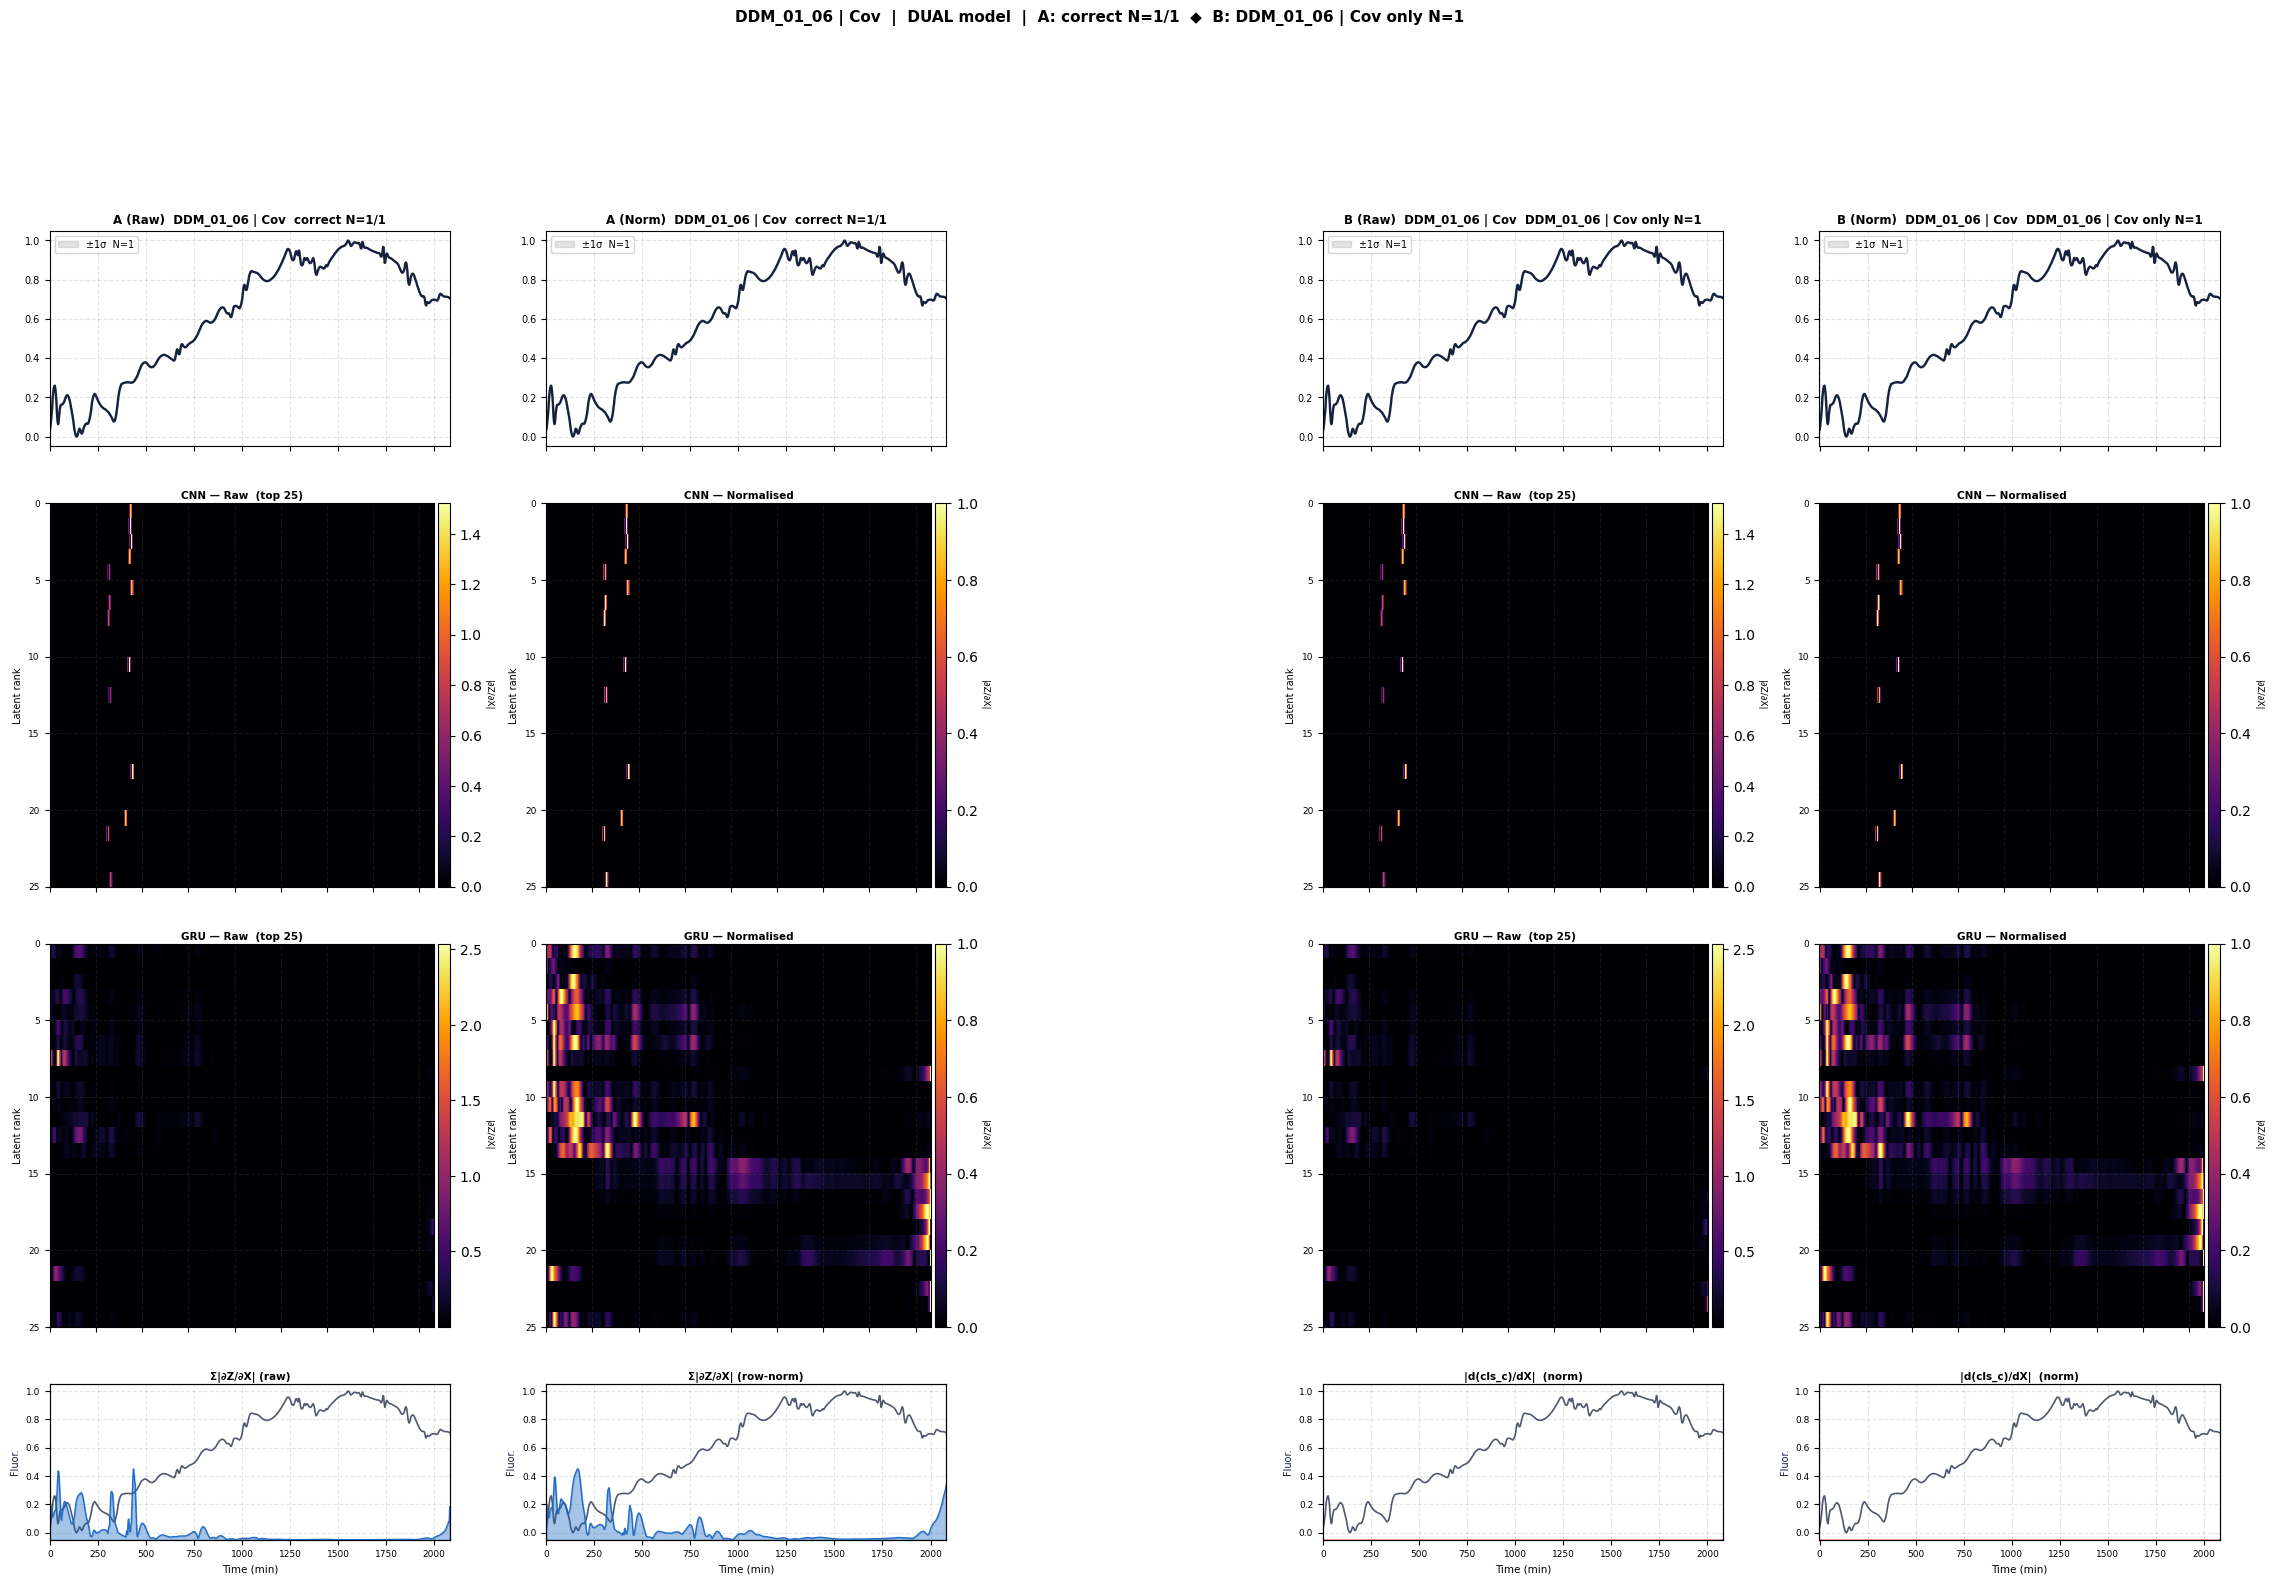

In [25]:
PREVIEW_ROW = 0   # index into sel_df

row = sel_df.iloc[PREVIEW_ROW]
j = PREVIEW_ROW
model_name = XAI_MODEL
model = models_xai[model_name]
art_j = _slice_art(art_all[model_name], j)

plot_per_label_saliency_heatmap(
    art_j, model, X_sel[j:j + 1], np.array([row["label_idx"]]), np.array([row["label_idx"]]),
    class_idx=row["label_idx"], class_name=f"{row['chip_short']} | {row['label']}",
    timestamps=timestamps, n_dims=N_DIMS, sample_scope=SAMPLE_SCOPE,
    save_path=None,
)
